# 🚀 Compressible CFD: From Scalar Dissipation to Wave-Resolving Fluxes

In this tutorial, we study numerical fluxes for the 1D Euler equations using the Sod shock tube problem.

We interpret flux schemes through a **unified dissipation framework**:

- Scalar dissipation → LLF (Rusanov)
- Local wave speeds → Kurganov–Tadmor (KT)
- Wave-resolving → HLLC

The goal is to understand **how numerical schemes encode physical information**.

## 🧠 Governing Equations: 1D Euler System

We solve the 1D compressible Euler equations in conservation form:

$$
\frac{\partial \mathbf{U}}{\partial t} + \frac{\partial \mathbf{F}(\mathbf{U})}{\partial x} = 0
$$

where the conserved variables are:

$$
\mathbf{U} =
\begin{bmatrix}
\rho \\
\rho u \\
E
\end{bmatrix}
$$

and the flux vector is:

$$
\mathbf{F}(\mathbf{U}) =
\begin{bmatrix}
\rho u \\
\rho u^2 + p \\
u(E + p)
\end{bmatrix}
$$

The system is closed using the ideal gas equation:

$$
p = (\gamma - 1)\left(E - \frac{1}{2}\rho u^2\right)
$$

## ⚡ Hyperbolic Nature and Wave Structure

The Euler equations are **nonlinear hyperbolic PDEs**.

They admit three characteristic waves:

1. Left-moving wave
2. Contact discontinuity (moves with velocity \(u\))
3. Right-moving wave

These waves lead to:
- Shock waves
- Rarefaction fans
- Contact discontinuities

👉 Any numerical method must approximate **how these waves propagate**.

## 🔧 Finite Volume Discretization

We divide the domain into cells and integrate:

$$
\frac{d \mathbf{U}_i}{dt}
= -\frac{1}{\Delta x}
\left( \mathbf{F}_{i+1/2} - \mathbf{F}_{i-1/2} \right)
$$

The key problem is:

> How do we compute the interface flux $ \mathbf{F}_{i+1/2} $?

At each interface, we have two states:
- Left state \(U_L\)
- Right state \(U_R\)

👉 This creates a **local Riemann problem**

All numerical schemes differ in how they approximate:

$$
\mathbf{F}(U_L, U_R)
$$

## 🔥 Unified Form of Numerical Fluxes

Most schemes can be written as:

$$
\mathbf{F} = \mathbf{F}_{central} - D (U_R - U_L)
$$

where:

- $ \mathbf{F}_{central} = \frac{1}{2}(F_L + F_R) $
- $ D $ = numerical dissipation operator

👉 The entire difference between schemes lies in how we define \(D\)

## ❗ Why Do We Need Numerical Dissipation?

Pure central schemes (no dissipation) are:

- Unstable
- Oscillatory near shocks

Because:
- Information propagates along characteristics
- Discontinuities generate non-physical oscillations

👉 Dissipation acts like:

- A stabilizer
- A shock-capturing mechanism

But too much dissipation → loss of physics

👉 The goal:
Balance **stability vs accuracy**

## 🟢 Scalar Dissipation: LLF (Rusanov)

### 💡 Idea

Assume all information travels at a single maximum speed:

$$
\alpha = \max(|u| + c)
$$

### 📌 Flux Formula

$$
F_{LLF} =
\frac{1}{2}(F_L + F_R)
- \frac{1}{2}\alpha (U_R - U_L)
$$

### 🧠 Physical Intuition

- Treats all waves equally
- No distinction between shock, contact, rarefaction

👉 Equivalent to:
"Everything moves at worst-case speed"

### ✔ Pros
- Very robust
- Simple

### ❌ Cons
- Highly diffusive
- Smears contact discontinuities

## 🟣 Local Wave Speed: Kurganov–Tadmor (KT)

### 💡 Idea

Instead of one speed, use directional speeds:

$$
a^+ = \max(0, \lambda_{max}), \quad
a^- = \min(0, \lambda_{min})
$$

### 📌 Flux Formula

$$
F_{KT} =
\frac{a^+ F_L - a^- F_R}{a^+ - a^-}
+ \frac{a^+ a^-}{a^+ - a^-}(U_R - U_L)
$$

### 🧠 Physical Intuition

- Separates left-going and right-going information
- Introduces directionality

👉 Improvement over LLF:
- Less diffusion
- Better wave separation

### ✔ Pros
- Simple
- More accurate than LLF

### ❌ Cons
- No explicit contact wave

## 🔵 Wave-Resolving Flux: HLLC

### 💡 Idea

Model the actual wave structure:

- Left wave $S_L$
- Contact wave $S_*$
- Right wave $S_R$

### 📌 Flux Structure

$$
F_{HLLC} =
\begin{cases}
F_L & S_L > 0 \\
F_*^L & S_L \le 0 \le S_* \\
F_*^R & S_* \le 0 \le S_R \\
F_R & S_R < 0
\end{cases}
$$

### 🧠 Physical Intuition

- Resolves contact discontinuity explicitly
- Preserves wave structure

👉 This is closest to the true Riemann solution

### ✔ Pros
- Sharp shocks
- Accurate contact

### ❌ Cons
- More complex

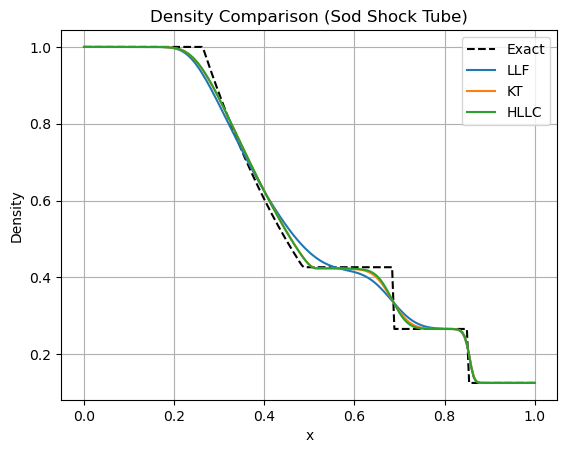


L1 Errors (Density):
LLF   : 1.672596e-02
KT    : 1.188310e-02
HLLC  : 1.115685e-02


In [4]:
# ============================================================
# 1D Euler Solver (Sod Shock Tube)
# LLF vs KT vs HLLC + Exact Toro Solution + L1 Error
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

GAMMA = 1.4


# ============================================================
# 1. Conversions
# ============================================================

def primitive_to_conservative(rho, u, p):
    E = p/(GAMMA - 1.0) + 0.5 * rho * u**2
    return np.array([rho, rho*u, E])


def conservative_to_primitive(U):
    rho = U[0]
    u = U[1] / rho
    E = U[2]
    p = (GAMMA - 1.0) * (E - 0.5 * rho * u**2)
    return rho, u, p


def flux(U):
    rho, u, p = conservative_to_primitive(U)
    return np.array([
        rho * u,
        rho * u**2 + p,
        u * (U[2] + p)
    ])


def sound_speed(U):
    rho, u, p = conservative_to_primitive(U)
    return np.sqrt(GAMMA * p / rho)


# ============================================================
# 2. Flux Schemes
# ============================================================

def flux_llf(UL, UR):
    FL = flux(UL)
    FR = flux(UR)

    aL = abs(UL[1]/UL[0]) + sound_speed(UL)
    aR = abs(UR[1]/UR[0]) + sound_speed(UR)
    alpha = max(aL, aR)

    return 0.5*(FL + FR) - 0.5*alpha*(UR - UL)


def flux_kt(UL, UR):
    FL = flux(UL)
    FR = flux(UR)

    uL, cL = UL[1]/UL[0], sound_speed(UL)
    uR, cR = UR[1]/UR[0], sound_speed(UR)

    a_plus  = max(0.0, uL + cL, uR + cR)
    a_minus = min(0.0, uL - cL, uR - cR)

    if (a_plus - a_minus) < 1e-12:
        return 0.5*(FL + FR)

    return (
        (a_plus * FL - a_minus * FR) / (a_plus - a_minus)
        + (a_plus * a_minus) / (a_plus - a_minus) * (UR - UL)
    )


def flux_hllc(UL, UR):

    rhoL, uL, pL = conservative_to_primitive(UL)
    rhoR, uR, pR = conservative_to_primitive(UR)

    cL = np.sqrt(GAMMA * pL / rhoL)
    cR = np.sqrt(GAMMA * pR / rhoR)

    SL = min(uL - cL, uR - cR)
    SR = max(uL + cL, uR + cR)

    S_star = (
        pR - pL + rhoL*uL*(SL - uL) - rhoR*uR*(SR - uR)
    ) / (rhoL*(SL - uL) - rhoR*(SR - uR))

    FL = flux(UL)
    FR = flux(UR)

    def U_star(U, S, S_star):
        rho, u, p = conservative_to_primitive(U)
        factor = rho * (S - u) / (S - S_star)
        E = U[2]
        return np.array([
            factor,
            factor * S_star,
            factor * (E/rho + (S_star - u)*(S_star + p/(rho*(S - u))))
        ])

    if SL >= 0:
        return FL
    elif SL <= 0 <= S_star:
        Ust = U_star(UL, SL, S_star)
        return FL + SL * (Ust - UL)
    elif S_star <= 0 <= SR:
        Ust = U_star(UR, SR, S_star)
        return FR + SR * (Ust - UR)
    else:
        return FR


# ============================================================
# 3. Solver Core
# ============================================================

def compute_flux(U, flux_type):
    nx = U.shape[1]
    F = np.zeros_like(U)

    for i in range(nx - 1):
        UL = U[:, i]
        UR = U[:, i+1]

        if flux_type == "llf":
            F[:, i] = flux_llf(UL, UR)
        elif flux_type == "kt":
            F[:, i] = flux_kt(UL, UR)
        elif flux_type == "hllc":
            F[:, i] = flux_hllc(UL, UR)

    return F


def time_step(U, dx, CFL):
    rho, u, p = conservative_to_primitive(U)
    c = np.sqrt(GAMMA * p / rho)
    return CFL * dx / np.max(np.abs(u) + c)


def evolve(U, dx, dt, flux_type):
    F = compute_flux(U, flux_type)

    U_new = U.copy()
    U_new[:, 1:-1] = U[:, 1:-1] - dt/dx * (F[:, 1:-1] - F[:, :-2])

    return U_new


# ============================================================
# 4. Initialization
# ============================================================

def initialize(nx):
    x = np.linspace(0, 1, nx)
    U = np.zeros((3, nx))

    for i in range(nx):
        if x[i] < 0.5:
            rho, u, p = 1.0, 0.0, 1.0
        else:
            rho, u, p = 0.125, 0.0, 0.1

        U[:, i] = primitive_to_conservative(rho, u, p)

    return x, U


# ============================================================
# 5. Exact Sod (Toro - CORRECT)
# ============================================================

def exact_sod(x, t, gamma=1.4):

    rho_l, u_l, p_l = 1.0, 0.0, 1.0
    rho_r, u_r, p_r = 0.125, 0.0, 0.1

    c_l = np.sqrt(gamma * p_l / rho_l)
    c_r = np.sqrt(gamma * p_r / rho_r)

    def phi(p, rho, p0, c):
        if p > p0:
            A = 2.0 / ((gamma + 1) * rho)
            B = (gamma - 1) / (gamma + 1) * p0
            return (p - p0) * np.sqrt(A / (p + B))
        else:
            return (2.0 * c / (gamma - 1)) * ((p / p0)**((gamma - 1) / (2 * gamma)) - 1.0)

    def f(p):
        return phi(p, rho_l, p_l, c_l) + phi(p, rho_r, p_r, c_r)

    p_star = brentq(f, 1e-8, 10)

    u_star = 0.5 * (
        phi(p_star, rho_r, p_r, c_r) -
        phi(p_star, rho_l, p_l, c_l)
    )

    rho = np.zeros_like(x)
    u   = np.zeros_like(x)
    p   = np.zeros_like(x)

    for i, xi in enumerate(x):
        s = (xi - 0.5) / t

        # LEFT
        if s <= u_star:
            if p_star > p_l:
                sL = u_l - c_l * np.sqrt((gamma + 1)/(2*gamma) * p_star/p_l + (gamma - 1)/(2*gamma))
                if s <= sL:
                    rho[i], u[i], p[i] = rho_l, u_l, p_l
                else:
                    rho_star_L = rho_l * ((p_star/p_l + (gamma-1)/(gamma+1)) /
                                          ((gamma-1)/(gamma+1)*p_star/p_l + 1))
                    rho[i], u[i], p[i] = rho_star_L, u_star, p_star
            else:
                c_star = c_l * (p_star/p_l)**((gamma-1)/(2*gamma))
                s_head = u_l - c_l
                s_tail = u_star - c_star

                if s <= s_head:
                    rho[i], u[i], p[i] = rho_l, u_l, p_l
                elif s < s_tail:
                    u[i] = 2.0/(gamma+1) * (c_l + (gamma-1)/2*u_l + s)
                    c = u[i] - s
                    p[i] = p_l * (c/c_l)**(2*gamma/(gamma-1))
                    rho[i] = rho_l * (p[i]/p_l)**(1/gamma)
                else:
                    rho_star_L = rho_l * (p_star/p_l)**(1/gamma)
                    rho[i], u[i], p[i] = rho_star_L, u_star, p_star

        # RIGHT
        else:
            if p_star > p_r:
                sR = u_r + c_r * np.sqrt((gamma + 1)/(2*gamma) * p_star/p_r + (gamma - 1)/(2*gamma))
                if s >= sR:
                    rho[i], u[i], p[i] = rho_r, u_r, p_r
                else:
                    rho_star_R = rho_r * ((p_star/p_r + (gamma-1)/(gamma+1)) /
                                          ((gamma-1)/(gamma+1)*p_star/p_r + 1))
                    rho[i], u[i], p[i] = rho_star_R, u_star, p_star
            else:
                c_star = c_r * (p_star/p_r)**((gamma-1)/(2*gamma))
                s_head = u_r + c_r
                s_tail = u_star + c_star

                if s >= s_head:
                    rho[i], u[i], p[i] = rho_r, u_r, p_r
                elif s > s_tail:
                    u[i] = 2.0/(gamma+1) * (-c_r + (gamma-1)/2*u_r + s)
                    c = s - u[i]
                    p[i] = p_r * (c/c_r)**(2*gamma/(gamma-1))
                    rho[i] = rho_r * (p[i]/p_r)**(1/gamma)
                else:
                    rho_star_R = rho_r * (p_star/p_r)**(1/gamma)
                    rho[i], u[i], p[i] = rho_star_R, u_star, p_star

    return rho, u, p


# ============================================================
# 6. Run Solver
# ============================================================

def run_solver(flux_type, nx=200, CFL=0.5, t_final=0.2):

    dx = 1.0 / nx
    x, U = initialize(nx)

    t = 0.0
    while t < t_final:
        dt = time_step(U, dx, CFL)
        if t + dt > t_final:
            dt = t_final - t

        U = evolve(U, dx, dt, flux_type)
        t += dt

    rho, u, p = conservative_to_primitive(U)
    return x, rho, u, p


# ============================================================
# 7. L1 Error
# ============================================================

def L1_error(num, exact):
    return np.mean(np.abs(num - exact))


# ============================================================
# 8. Main
# ============================================================

if __name__ == "__main__":

    schemes = ["llf", "kt", "hllc"]
    results = {}

    for scheme in schemes:
        x, rho, u, p = run_solver(scheme)
        results[scheme] = rho

    rho_ex, _, _ = exact_sod(x, t=0.2)

    # Plot
    plt.figure()
    plt.plot(x, rho_ex, 'k--', label="Exact")

    for scheme in schemes:
        plt.plot(x, results[scheme], label=scheme.upper())

    plt.legend()
    plt.title("Density Comparison (Sod Shock Tube)")
    plt.xlabel("x")
    plt.ylabel("Density")
    plt.grid()
    plt.show()

    # Errors
    print("\nL1 Errors (Density):")
    for scheme in schemes:
        err = L1_error(results[scheme], rho_ex)
        print(f"{scheme.upper():5s} : {err:.6e}")

## 🔥 Comparison: Information Content

All schemes differ in **how much physics they retain**

| Scheme | Dissipation Type | Physics Awareness |
|--------|----------------|------------------|
| LLF    | Scalar         | Minimal          |
| KT     | Directional    | Moderate         |
| HLLC   | Wave-based     | High             |

👉 Increasing accuracy comes from:
> Increasing wave information in the flux

## 🎯 Final Insight

Numerical fluxes are not different methods —

They are **different approximations of the same idea**:

$$
F = F_{central} - D (U_R - U_L)
$$

Where:

- LLF → scalar dissipation
- KT → directional dissipation
- HLLC → wave-structured dissipation

👉 CFD evolved from:
- Stability-driven methods
→ Direction-aware methods
→ Physics-resolving methods

## 🏭 Examples of Flux Schemes in CFD Software

Different CFD solvers implement different numerical flux philosophies.
However, they are not always exposed using the same names (LLF, KT, HLLC).

Below is a mapping between theory and practice:

---

### 🟢 Scalar Dissipation (LLF / Rusanov)

- Rarely used in production CFD due to high numerical diffusion

**Examples:**
- Used in:
  - Research codes
  - Teaching implementations
  - Prototype solvers
- Sometimes used internally for:
  - Initialization
  - Stabilization
  - Fallback flux

**Software:**
- Not explicitly available in:
  - ANSYS Fluent
  - CFX
  - STAR-CCM+
  - SU2
  - OpenFOAM (not default)

👉 Conclusion:
LLF is mainly a **baseline/reference method**, not an industrial solver

---

### 🟣 Local Wave Speed (KT / Central Schemes)

These belong to **central schemes with local propagation speeds**

**Examples:**
- Kurganov–Tadmor (KT)
- Central-upwind schemes

**Software:**

- OpenFOAM:
  - `rhoCentralFoam` → Kurganov–Tadmor (KT) ✅

- SU2:
  - JST (Jameson–Schmidt–Turkel)
  → central scheme with artificial dissipation (KT-like)

- ANSYS CFX:
  - High-resolution central schemes with added dissipation

👉 Conclusion:
KT-type methods are widely used in **central schemes**

---

### 🔵 Wave-Based (HLLC / Roe)

These are **Riemann-based upwind solvers**

**Examples:**
- HLLC
- Roe
- HLL

**Software:**

- OpenFOAM:
  - HLLC (dbnsFoam, blastFoam- Community Solvers & Add-ons)

- SU2:
  - Roe
  - HLLC
  - AUSM+

- STAR-CCM+:
  - Roe
  - HLLC
  - AUSM+up

- ANSYS Fluent:
  - Roe-FDS
  - AUSM family (similar wave-resolving behavior)

👉 Conclusion:
Wave-based solvers are the **standard for high-speed compressible flows**

---

## 🔥 Final Insight

| Category | Industrial Presence |
|----------|-------------------|
| LLF      | Rare (baseline only) |
| KT       | Moderate (central schemes) |
| HLLC     | Very common |

👉 Modern CFD tools favor methods that preserve **wave structure**